In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
import sys
import os

# Add parent directory to Python path
sys.path.insert(0, os.path.abspath('..'))

# Import FEM modules
from fem.core import Node, Material
from fem.sections import Membrane
from fem.elements import CST, LST, Quad4, Quad9
from fem.utils import get_line_load_global_vector

from fem.utils import add_element_data_view, add_node_data_view, compute_nodal_average
from fem.utils.functions import build_nodes_from_gmsh, create_elements_from_gmsh, build_load_vector

# Import standard libraries
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math

In [3]:
# General model parameters
L = 1000 
H = 1000  
B = 10
lc = 50
R = 200 
output_path = os.getcwd()
mesh_name = 'plate_with_hole'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Create the corner points of the beam
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)
p2 = gmsh.model.geo.addPoint(L, 0, 0, lc)
p3 = gmsh.model.geo.addPoint(L, H, 0, lc)
p4 = gmsh.model.geo.addPoint(0, H, 0, lc)

# Define the outer rectangle lines
l1 = gmsh.model.geo.addLine(p1, p2)  # Base
l2 = gmsh.model.geo.addLine(p2, p3)  # Lateral derecho
l3 = gmsh.model.geo.addLine(p3, p4)  # Tope
l4 = gmsh.model.geo.addLine(p4, p1)  # Lateral izquierdo

# Create the outer curve loop
c1 = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])

# Create the circular hole in the center (4 puntos para que sea divisible por 2)
center_x = L / 2
center_y = H / 2
pc = gmsh.model.geo.addPoint(center_x, center_y, 0, lc)
p_right = gmsh.model.geo.addPoint(center_x + R, center_y, 0, lc)
p_top = gmsh.model.geo.addPoint(center_x, center_y + R, 0, lc)
p_left = gmsh.model.geo.addPoint(center_x - R, center_y, 0, lc)
p_bottom = gmsh.model.geo.addPoint(center_x, center_y - R, 0, lc)

# Create four quarter-circle arcs
arc1 = gmsh.model.geo.addCircleArc(p_right, pc, p_top)
arc2 = gmsh.model.geo.addCircleArc(p_top, pc, p_left)
arc3 = gmsh.model.geo.addCircleArc(p_left, pc, p_bottom)
arc4 = gmsh.model.geo.addCircleArc(p_bottom, pc, p_right)

# Create the hole curve loop
c2 = gmsh.model.geo.addCurveLoop([arc1, arc2, arc3, arc4])

# Create the surface with the hole
s1 = gmsh.model.geo.addPlaneSurface([c1, c2])

# Synchronize the model
gmsh.model.geo.synchronize()

# Create the physical groups
gmsh.model.addPhysicalGroup(2, [s1], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

# Apoyo en lado izquierdo (empotrado)
gmsh.model.addPhysicalGroup(1, [l4], 101) 
gmsh.model.setPhysicalName(1, 101, "Support1")

# Carga en el lado derecho
gmsh.model.addPhysicalGroup(1, [l2], 50) 
gmsh.model.setPhysicalName(1, 50, "Load")

# Synchronize the model
gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

# all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)


# Generate and save mesh
# gmsh.model.mesh.generate()
# gmsh.write(output_file)
# gmsh.fltk.run()
# gmsh.finalize()

In [5]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Circle)
Info    : [ 70%] Meshing curve 6 (Circle)
Info    : [ 80%] Meshing curve 7 (Circle)
Info    : [ 90%] Meshing curve 8 (Circle)
Info    : Done meshing 1D (Wall 0.000839144s, CPU 0.010439s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00975857s, CPU 0.111962s)
Info    : Meshing 3D...
Info    : Done meshing 3D (Wall 7.80501e-06s, CPU 0.000153s)
Info    : 514 nodes 1035 elements
Info    : Writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : Done writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'
-------------------------------------------------------
Version       : 4.15.1
License       : GNU General Public License
Bu

Fontconfig warning: using without calling FcInit()


Info    : Writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : Done writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'


In [6]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho=1.25*0)

# Define membrane section
SteelPlate = Membrane(name='SteelPlate',
                        thickness=B,
                        material=Steel)

# Map physical group id to section
section_dictionary = {201: SteelPlate}
                    
# Load magnitude
Pload = 10
load_dictionary = {
    50: {'value': 10, 'direction': 'x'}
}

# Boundary conditions
restrain_dictionary = {101: ['r', 'r']}

# Self-weight (not used)
self_weight = [0, 0]

In [7]:
node_map, nodes = build_nodes_from_gmsh(
    output_file,
    restrain_dictionary=restrain_dictionary,
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : 18 entities
Info    : 513 nodes
Info    : 958 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'


In [8]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = create_elements_from_gmsh(
    output_file=output_file,
    node_map=node_map,
    section_dictionary=section_dictionary,
    element_class_map=element_map
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : 18 entities
Info    : 513 nodes
Info    : 958 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'


In [9]:
def plot_mesh(figsize=(25, 25),
              nodes=None, 
              elements=None,                
              show_node_labels=True, 
              show_element_labels=True):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot nodes if provided
    if nodes is not None:
        for node in nodes:
            node.plotGeometry(ax=ax, text=show_node_labels)
    # Plot elements if provided
    if elements is not None:
        for element in elements:
            element.plotGeometry(ax=ax)
            if show_element_labels:
                x, y = element.get_centroid()
                ax.text(x, y, f'{element.element_tag}', color='r', ha='center', fontsize=8)
    # Maintain 1:1 aspect ratio
    ax.set_aspect('equal')
    plt.show()

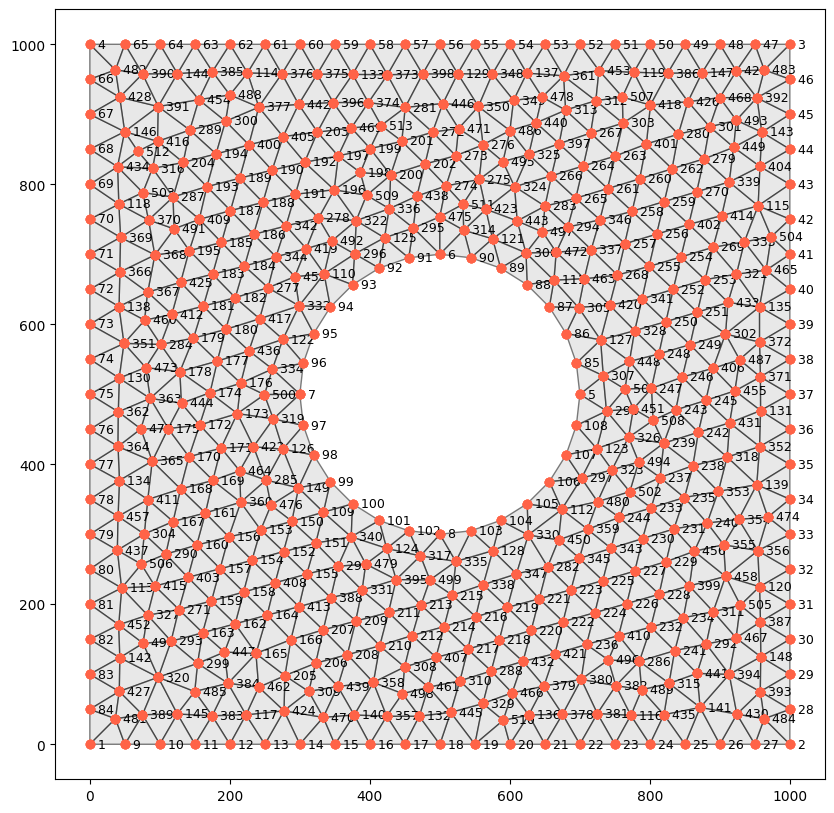

In [10]:
# Plot
plot_mesh(figsize=(10, 10) , 
          nodes=nodes,
            elements=elements, 
            show_node_labels=True, 
            show_element_labels=False)

In [11]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [12]:
F_load = build_load_vector(
    output_file=output_file,
    node_map=node_map,
    load_dictionary=load_dictionary,
    system_nDof=system_nDof
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : 18 entities
Info    : 513 nodes
Info    : 958 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'


In [13]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [14]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [15]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [1000. 1000.]:  ux=+0.005635  uy=+0.000304
Node 37 at [1000.  500.]:  ux=+0.008712  uy=-0.000004


In [16]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-606.394351  Ry=-189.085108
Node 4:  Rx=-606.622922  Ry=+188.530000
Node 66:  Rx=-835.678089  Ry=+111.188321
Node 67:  Rx=-710.815156  Ry=+63.799211
Node 68:  Rx=-626.953424  Ry=+20.121128
Node 69:  Rx=-550.551095  Ry=-1.186278
Node 70:  Rx=-469.225459  Ry=-24.962719
Node 71:  Rx=-384.212073  Ry=-46.093352
Node 72:  Rx=-306.509711  Ry=-52.511923
Node 73:  Rx=-237.833199  Ry=-48.709188
Node 74:  Rx=-187.968376  Ry=-24.028803
Node 75:  Rx=-171.162933  Ry=+0.779720
Node 76:  Rx=-187.638158  Ry=+27.112272
Node 77:  Rx=-235.400306  Ry=+45.426573
Node 78:  Rx=-303.956145  Ry=+53.066567
Node 79:  Rx=-384.968290  Ry=+43.849157
Node 80:  Rx=-467.028245  Ry=+31.539915
Node 81:  Rx=-548.222856  Ry=+1.102550
Node 82:  Rx=-632.624531  Ry=-27.751164
Node 83:  Rx=-711.112804  Ry=-60.657792
Node 84:  Rx=-835.121878  Ry=-111.529086
----------------------------------------------------------------------------------------------------
Applied X:  +10000.0000   Reaction X: -10000.0000   Balance:

In [17]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [18]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'...
Info    : 18 entities
Info    : 513 nodes
Info    : 958 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/plate_with_hole.msh'


2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

-------------------------------------------------------
Version       : 4.15.1
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260216
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------
